2025-03-28 00:07:40,582 - INFO - Loading spectral data...
2025-03-28 00:07:40,583 - INFO - Processing RGB data...
2025-03-28 00:07:40,584 - INFO - Normalizing RGB data...
2025-03-28 00:07:40,585 - INFO - Iteration 1/4 - Training the model...
2025-03-28 00:07:40,594 - INFO - Epoch 1/500 - Training Loss: 21.2869 - Validation Loss: 0.4892
2025-03-28 00:07:40,601 - INFO - Epoch 2/500 - Training Loss: 6.9480 - Validation Loss: 0.1824
2025-03-28 00:07:40,609 - INFO - Epoch 3/500 - Training Loss: 3.4143 - Validation Loss: 0.1156
2025-03-28 00:07:40,617 - INFO - Epoch 4/500 - Training Loss: 2.2647 - Validation Loss: 0.0797
2025-03-28 00:07:40,624 - INFO - Epoch 5/500 - Training Loss: 1.5980 - Validation Loss: 0.0597
2025-03-28 00:07:40,632 - INFO - Epoch 6/500 - Training Loss: 1.1810 - Validation Loss: 0.0463
2025-03-28 00:07:40,639 - INFO - Epoch 7/500 - Training Loss: 0.9236 - Validation Loss: 0.0391
2025-03-28 00:07:40,647 - INFO - Epoch 8/500 - Training Loss: 0.7932 - Validation Loss: 0.03

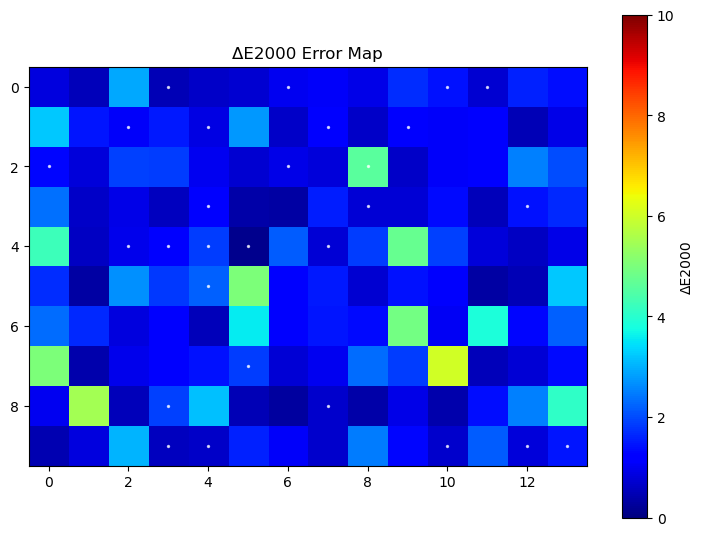

2025-03-28 00:07:55,742 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.022415453916988848..0.9903190359556762].


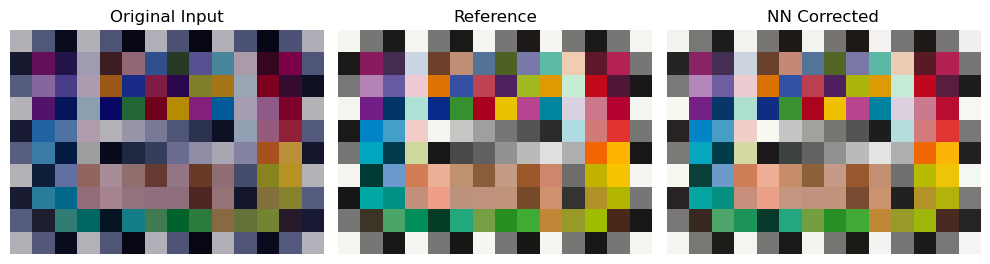

In [28]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
from sklearn.preprocessing import StandardScaler
import spectral
import random
from skimage import color
import matplotlib.pyplot as plt
import copy
import os

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set a fixed seed for reproducibility
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

###########################################
# Helper functions
###########################################
def process_rgb(cube, bands, ill, CMFs):
    ill_interp = np.interp(bands, ill[:, 0], ill[:, 1])
    CMFs_interp = np.column_stack([
        np.interp(bands, CMFs[:, 0], CMFs[:, 1]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 2]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 3])
    ])
    sp_tristREF = CMFs_interp * ill_interp[:, None]
    xyz = np.dot(cube, sp_tristREF) / np.sum(sp_tristREF[:, 1], axis=0)
    rgb = color.xyz2rgb(xyz)
    return rgb

###########################################
# 1. Load spectral data
###########################################
logging.info('Loading spectral data...')
ill = np.loadtxt('../../data/CIE_D65.txt')          
CMFs = np.loadtxt('../../data/CIE2degCMFs_1931.txt')

cube_path = '../../data/colorChecker_SG/cubes/cubeCC_120f-ekta100-f14.hdr'
cube = spectral.open_image(cube_path)
cube_ref = spectral.open_image('../../data/colorChecker_SG/cubeCC_DigitalSG_REF.hdr')

cube_data = cube.load()         
cube_ref_data = cube_ref.load()

wl_input = np.array(cube.metadata['wavelength'], dtype=float)
wl_ref = np.array(cube_ref.metadata['wavelength'], dtype=float)

###########################################
# 2. Process RGB data
###########################################
logging.info('Processing RGB data...')
rgb_input = process_rgb(cube_data, wl_input, ill, CMFs)   
rgb_ref = process_rgb(cube_ref_data, wl_ref, ill, CMFs)   

###########################################
# 3. Normalize data in RGB space
###########################################
logging.info('Normalizing RGB data...')
X_flat = rgb_input.reshape(-1, 3)
Y_flat = rgb_ref.reshape(-1, 3)

scaler_input = StandardScaler()
scaler_ref = StandardScaler()

###########################################
# 4. Define MLP Model
###########################################
class SimpleMLP(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, output_size=3):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

# Training settings
num_iterations = 4  # Number of iterative refinement steps
epochs = 500
batch_size = 4
alpha = 0.6  # Blending factor for residual learning

for iteration in range(num_iterations):
    logging.info(f'Iteration {iteration + 1}/{num_iterations} - Training the model...')

    # Dynamically update normalization
    X_norm = scaler_input.fit_transform(X_flat)
    Y_norm = scaler_ref.fit_transform(Y_flat)

    X_train_torch = torch.tensor(X_norm, dtype=torch.float32)
    Y_train_torch = torch.tensor(Y_norm, dtype=torch.float32)

    # Split into train/test
    n_pixels = X_norm.shape[0]
    train_size = int(0.8 * n_pixels)
    train_indices = np.random.choice(n_pixels, train_size, replace=False)
    test_indices = np.setdiff1d(np.arange(n_pixels), train_indices)

    X_train = X_train_torch[train_indices]
    Y_train = Y_train_torch[train_indices]
    X_test = X_train_torch[test_indices]
    Y_test = Y_train_torch[test_indices]

    # Initialize model
    model = SimpleMLP()
    optimizer = optim.Adam(model.parameters(), lr=0.001 / (iteration + 1), weight_decay=1e-5)  
    loss_function = nn.MSELoss()

    # Training loop
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        perm = torch.randperm(X_train.size(0))
        for i in range(0, X_train.size(0), batch_size):
            batch_indices = perm[i:i+batch_size]
            X_batch = X_train[batch_indices]
            Y_batch = Y_train[batch_indices]

            optimizer.zero_grad()
            Y_pred = model(X_batch)
            loss = loss_function(Y_pred, Y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Validation loss
        model.eval()
        with torch.no_grad():
            Y_val_pred = model(X_test)
            val_loss = loss_function(Y_val_pred, Y_test).item()
        
        logging.info(f'Epoch {epoch+1}/{epochs} - Training Loss: {epoch_loss:.4f} - Validation Loss: {val_loss:.4f}')

    # Apply correction
    model.eval()
    with torch.no_grad():
        corrected_flat = model(torch.tensor(X_norm, dtype=torch.float32)).numpy()

    # Residual learning: mix original with corrected
    X_flat = alpha * corrected_flat + (1 - alpha) * X_flat  

# Final correction
corrected_rgb = scaler_ref.inverse_transform(X_flat)
corrected_rgb_image = corrected_rgb.reshape(rgb_ref.shape)

###########################################
# 5. Compute ΔE2000 Error Maps
###########################################
logging.info('Computing ΔE2000 error map...')
corrected_lab = color.rgb2lab(corrected_rgb_image)
lab_ref = color.rgb2lab(rgb_ref)

# Compute ΔE2000 error
error_map = color.deltaE_ciede2000(lab_ref, corrected_lab)

# Compute mean & max error
error_map_flat = error_map.reshape(-1)
test_error_values = error_map_flat[test_indices]
mean_error_test = np.mean(test_error_values)
max_error_test = np.max(test_error_values)

logging.info(f"Mean ΔE2000 Error: {mean_error_test:.2f}")
logging.info(f"Max ΔE2000 Error: {max_error_test:.2f}")

# Get test pixel positions
test_positions = np.unravel_index(test_indices, lab_ref.shape[:2])

# Plot error map
plt.figure(figsize=(8, 6))
plt.imshow(error_map, cmap='jet', vmin=0, vmax=10)
plt.colorbar(label='ΔE2000')
plt.scatter(test_positions[1], test_positions[0], s=2, c='white', label='Test Patches', alpha=0.7)
plt.title('ΔE2000 Error Map')
plt.tight_layout(pad=3.0)
plt.show()

# Comparison plot
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(rgb_input)
plt.title('Original Input')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(rgb_ref)
plt.title('Reference')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(corrected_rgb_image)
plt.title('NN Corrected')
plt.axis('off')
plt.tight_layout()
plt.show()


2025-03-28 00:07:55,800 - INFO - Loading spectral data...
2025-03-28 00:07:55,801 - INFO - Processing RGB data...
2025-03-28 00:07:55,802 - INFO - Normalizing RGB data...
2025-03-28 00:07:55,802 - INFO - Iteration 1/4
2025-03-28 00:07:55,811 - INFO - Epoch 1/500 - Train Loss: 21.2869 - Val Loss: 0.4892
2025-03-28 00:07:55,819 - INFO - Epoch 2/500 - Train Loss: 6.9480 - Val Loss: 0.1824
2025-03-28 00:07:55,826 - INFO - Epoch 3/500 - Train Loss: 3.4143 - Val Loss: 0.1156


2025-03-28 00:07:55,833 - INFO - Epoch 4/500 - Train Loss: 2.2647 - Val Loss: 0.0797
2025-03-28 00:07:55,841 - INFO - Epoch 5/500 - Train Loss: 1.5980 - Val Loss: 0.0597
2025-03-28 00:07:55,848 - INFO - Epoch 6/500 - Train Loss: 1.1810 - Val Loss: 0.0463
2025-03-28 00:07:55,856 - INFO - Epoch 7/500 - Train Loss: 0.9236 - Val Loss: 0.0391
2025-03-28 00:07:55,863 - INFO - Epoch 8/500 - Train Loss: 0.7932 - Val Loss: 0.0339
2025-03-28 00:07:55,871 - INFO - Epoch 9/500 - Train Loss: 0.6961 - Val Loss: 0.0314
2025-03-28 00:07:55,878 - INFO - Epoch 10/500 - Train Loss: 0.6361 - Val Loss: 0.0297
2025-03-28 00:07:55,886 - INFO - Epoch 11/500 - Train Loss: 0.5887 - Val Loss: 0.0280
2025-03-28 00:07:55,893 - INFO - Epoch 12/500 - Train Loss: 0.5599 - Val Loss: 0.0267
2025-03-28 00:07:55,900 - INFO - Epoch 13/500 - Train Loss: 0.5522 - Val Loss: 0.0275
2025-03-28 00:07:55,908 - INFO - Epoch 14/500 - Train Loss: 0.5271 - Val Loss: 0.0274
2025-03-28 00:07:55,915 - INFO - Epoch 15/500 - Train Loss: 

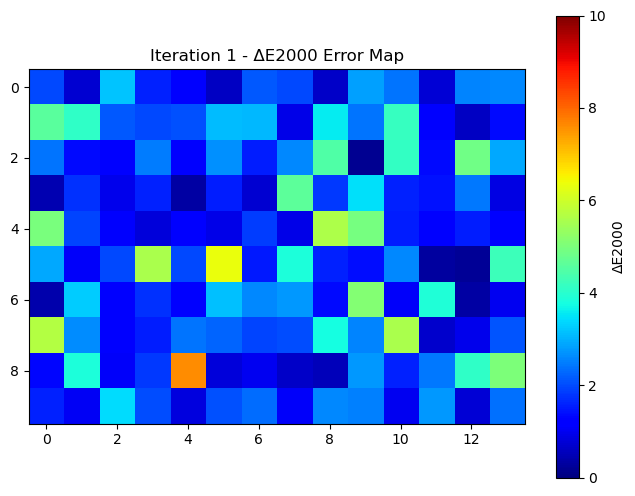

2025-03-28 00:07:57,983 - INFO - Iteration 2/4
2025-03-28 00:07:57,993 - INFO - Epoch 1/500 - Train Loss: 24.5018 - Val Loss: 0.6235
2025-03-28 00:07:58,001 - INFO - Epoch 2/500 - Train Loss: 14.6258 - Val Loss: 0.3888
2025-03-28 00:07:58,009 - INFO - Epoch 3/500 - Train Loss: 8.4444 - Val Loss: 0.2422
2025-03-28 00:07:58,016 - INFO - Epoch 4/500 - Train Loss: 4.9763 - Val Loss: 0.1551
2025-03-28 00:07:58,024 - INFO - Epoch 5/500 - Train Loss: 3.0548 - Val Loss: 0.1088
2025-03-28 00:07:58,031 - INFO - Epoch 6/500 - Train Loss: 2.1123 - Val Loss: 0.0784
2025-03-28 00:07:58,039 - INFO - Epoch 7/500 - Train Loss: 1.5436 - Val Loss: 0.0576
2025-03-28 00:07:58,046 - INFO - Epoch 8/500 - Train Loss: 1.1632 - Val Loss: 0.0435
2025-03-28 00:07:58,053 - INFO - Epoch 9/500 - Train Loss: 0.9046 - Val Loss: 0.0343
2025-03-28 00:07:58,061 - INFO - Epoch 10/500 - Train Loss: 0.7241 - Val Loss: 0.0272
2025-03-28 00:07:58,068 - INFO - Epoch 11/500 - Train Loss: 0.5987 - Val Loss: 0.0225
2025-03-28 00:

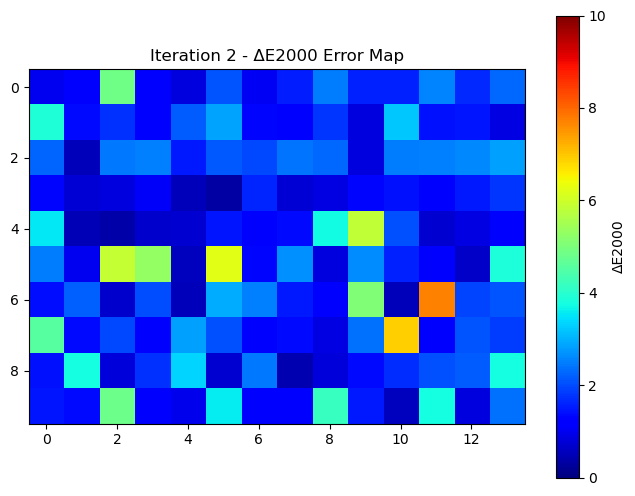

2025-03-28 00:08:01,477 - INFO - Iteration 3/4
2025-03-28 00:08:01,487 - INFO - Epoch 1/500 - Train Loss: 18.9378 - Val Loss: 0.4058
2025-03-28 00:08:01,494 - INFO - Epoch 2/500 - Train Loss: 12.4641 - Val Loss: 0.2604
2025-03-28 00:08:01,502 - INFO - Epoch 3/500 - Train Loss: 8.4276 - Val Loss: 0.1691
2025-03-28 00:08:01,510 - INFO - Epoch 4/500 - Train Loss: 5.7701 - Val Loss: 0.1140
2025-03-28 00:08:01,518 - INFO - Epoch 5/500 - Train Loss: 4.1682 - Val Loss: 0.0785
2025-03-28 00:08:01,525 - INFO - Epoch 6/500 - Train Loss: 3.0598 - Val Loss: 0.0571
2025-03-28 00:08:01,533 - INFO - Epoch 7/500 - Train Loss: 2.3528 - Val Loss: 0.0420
2025-03-28 00:08:01,541 - INFO - Epoch 8/500 - Train Loss: 1.8001 - Val Loss: 0.0319
2025-03-28 00:08:01,548 - INFO - Epoch 9/500 - Train Loss: 1.4269 - Val Loss: 0.0238
2025-03-28 00:08:01,557 - INFO - Epoch 10/500 - Train Loss: 1.1178 - Val Loss: 0.0184
2025-03-28 00:08:01,564 - INFO - Epoch 11/500 - Train Loss: 0.8978 - Val Loss: 0.0144
2025-03-28 00:

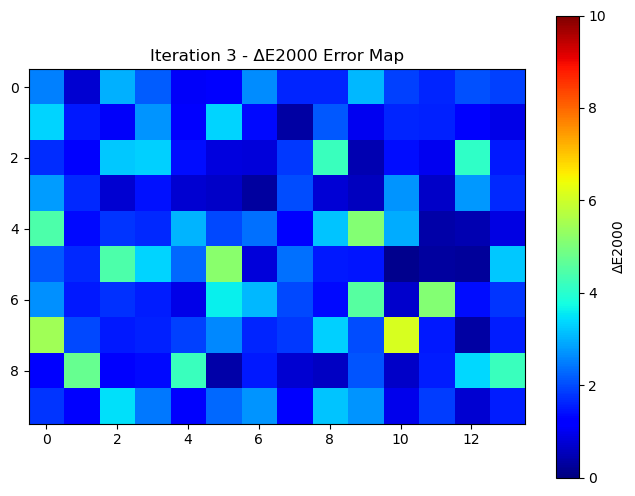

2025-03-28 00:08:02,785 - INFO - Iteration 4/4
2025-03-28 00:08:02,794 - INFO - Epoch 1/500 - Train Loss: 24.4737 - Val Loss: 0.7652
2025-03-28 00:08:02,802 - INFO - Epoch 2/500 - Train Loss: 18.7762 - Val Loss: 0.5717
2025-03-28 00:08:02,809 - INFO - Epoch 3/500 - Train Loss: 14.4138 - Val Loss: 0.4323
2025-03-28 00:08:02,816 - INFO - Epoch 4/500 - Train Loss: 11.2516 - Val Loss: 0.3300
2025-03-28 00:08:02,824 - INFO - Epoch 5/500 - Train Loss: 8.8479 - Val Loss: 0.2599
2025-03-28 00:08:02,831 - INFO - Epoch 6/500 - Train Loss: 7.1263 - Val Loss: 0.2045
2025-03-28 00:08:02,840 - INFO - Epoch 7/500 - Train Loss: 5.7926 - Val Loss: 0.1666
2025-03-28 00:08:02,848 - INFO - Epoch 8/500 - Train Loss: 4.7629 - Val Loss: 0.1368
2025-03-28 00:08:02,856 - INFO - Epoch 9/500 - Train Loss: 3.9970 - Val Loss: 0.1142
2025-03-28 00:08:02,863 - INFO - Epoch 10/500 - Train Loss: 3.3677 - Val Loss: 0.0956
2025-03-28 00:08:02,871 - INFO - Epoch 11/500 - Train Loss: 2.8370 - Val Loss: 0.0819
2025-03-28 0

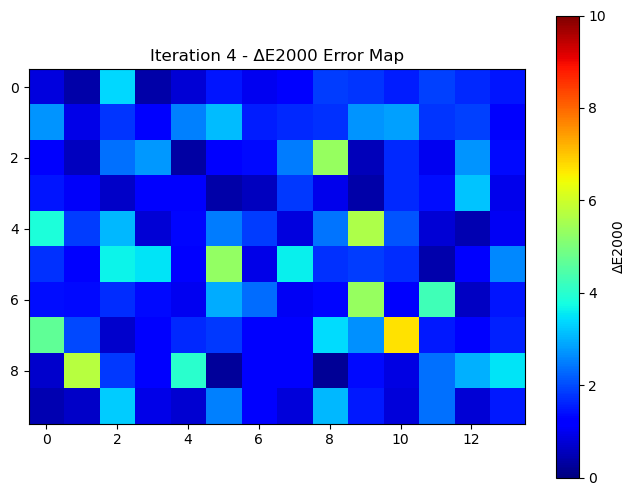

2025-03-28 00:08:04,055 - INFO - Final error evaluation:
2025-03-28 00:08:04,055 - INFO - Final Mean ΔE2000 Error: 1.45
2025-03-28 00:08:04,055 - INFO - Final Max ΔE2000 Error: 4.80


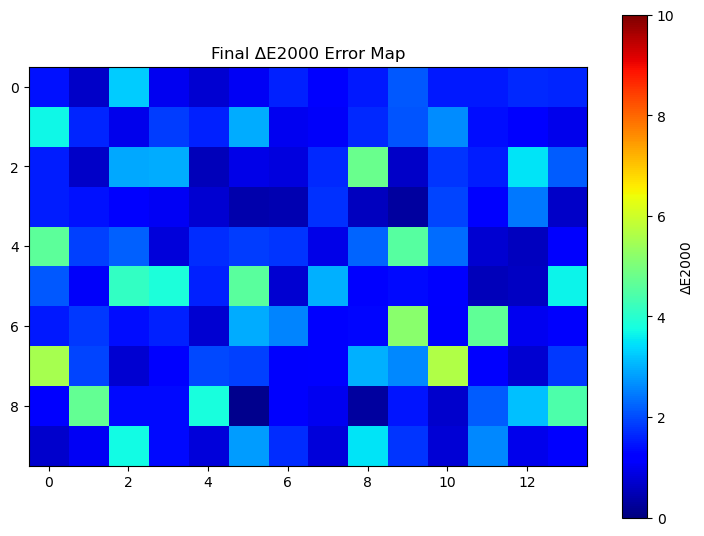

2025-03-28 00:08:04,150 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05501286064630345..1.0000079886904232].


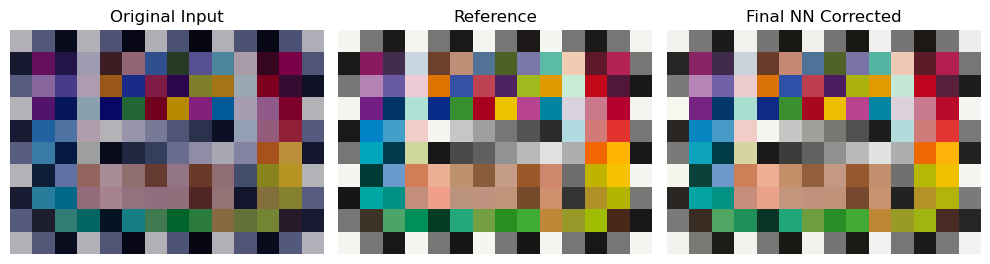

In [29]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
from sklearn.preprocessing import StandardScaler
import spectral
import random
from skimage import color
import matplotlib.pyplot as plt
import copy
import os

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set a fixed seed for reproducibility
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

###########################################
# Helper functions
###########################################
def process_rgb(cube, bands, ill, CMFs):
    """Converts hyperspectral cube data to RGB using XYZ conversion."""
    ill_interp = np.interp(bands, ill[:, 0], ill[:, 1])
    CMFs_interp = np.column_stack([
        np.interp(bands, CMFs[:, 0], CMFs[:, 1]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 2]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 3])
    ])
    sp_tristREF = CMFs_interp * ill_interp[:, None]
    xyz = np.dot(cube, sp_tristREF) / np.sum(sp_tristREF[:, 1], axis=0)
    rgb = color.xyz2rgb(xyz)
    return rgb

###########################################
# Early stopping class
###########################################
class EarlyStopping:
    """Stops training if validation loss doesn't improve after a set patience."""
    def __init__(self, patience=20, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss):
        if val_loss + self.min_delta < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0  # Reset patience
        else:
            self.counter += 1  # Increment patience
        return self.counter >= self.patience  # Return True if no improvement

###########################################
# 1. Load spectral data
###########################################
logging.info('Loading spectral data...')
ill = np.loadtxt('../../data/CIE_D65.txt')          
CMFs = np.loadtxt('../../data/CIE2degCMFs_1931.txt')

cube_path = '../../data/colorChecker_SG/cubes/cubeCC_120f-ekta100-f14.hdr'
cube = spectral.open_image(cube_path)
cube_ref = spectral.open_image('../../data/colorChecker_SG/cubeCC_DigitalSG_REF.hdr')

cube_data = cube.load()         
cube_ref_data = cube_ref.load()

wl_input = np.array(cube.metadata['wavelength'], dtype=float)
wl_ref   = np.array(cube_ref.metadata['wavelength'], dtype=float)

###########################################
# 2. Process RGB data
###########################################
logging.info('Processing RGB data...')
rgb_input = process_rgb(cube_data, wl_input, ill, CMFs)   
rgb_ref   = process_rgb(cube_ref_data, wl_ref, ill, CMFs)   

H, W, C = rgb_input.shape

###########################################
# 3. Normalize data in RGB space
###########################################
logging.info('Normalizing RGB data...')
# Flatten the images so each pixel is a sample
X_flat = rgb_input.reshape(-1, 3)
Y_flat = rgb_ref.reshape(-1, 3)

scaler_input = StandardScaler()
scaler_ref = StandardScaler()

###########################################
# 4. Define the MLP model
###########################################
class SimpleMLP(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, output_size=3):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

###########################################
# 5. Iterative Training with Early Stopping and Residual Learning (Blending)
###########################################
iterations = 4       # Number of refinement steps
epochs = 500         # Maximum epochs per iteration
batch_size = 4
alpha = 0.6          # Blending factor for residual learning

for iter_num in range(iterations):
    logging.info(f"Iteration {iter_num + 1}/{iterations}")

    # Dynamically update normalization for current data
    X_norm = scaler_input.fit_transform(X_flat)
    Y_norm = scaler_ref.fit_transform(Y_flat)

    # Convert normalized data to torch tensors
    X_tensor = torch.tensor(X_norm, dtype=torch.float32)
    Y_tensor = torch.tensor(Y_norm, dtype=torch.float32)

    # Split into training (80%) and test (20%) sets
    n_pixels = X_norm.shape[0]
    train_size = int(0.8 * n_pixels)
    train_indices = np.random.choice(n_pixels, train_size, replace=False)
    test_indices = np.setdiff1d(np.arange(n_pixels), train_indices)

    X_train = X_tensor[train_indices]
    Y_train = Y_tensor[train_indices]
    X_test = X_tensor[test_indices]
    Y_test = Y_tensor[test_indices]

    # Initialize model, optimizer, loss function, and early stopping
    model = SimpleMLP()
    optimizer = optim.Adam(model.parameters(), lr=0.001 / (iter_num + 1), weight_decay=1e-5)
    loss_function = nn.MSELoss()
    early_stopping = EarlyStopping(patience=50, min_delta=1e-5)

    # Training loop with early stopping
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        perm = torch.randperm(X_train.size(0))
        for i in range(0, X_train.size(0), batch_size):
            batch_indices = perm[i:i+batch_size]
            X_batch = X_train[batch_indices]
            Y_batch = Y_train[batch_indices]

            optimizer.zero_grad()
            Y_pred = model(X_batch)
            loss = loss_function(Y_pred, Y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Compute validation loss on test set
        model.eval()
        with torch.no_grad():
            Y_val_pred = model(X_test)
            val_loss = loss_function(Y_val_pred, Y_test).item()

        logging.info(f'Epoch {epoch+1}/{epochs} - Train Loss: {epoch_loss:.4f} - Val Loss: {val_loss:.4f}')
        if early_stopping(val_loss):
            logging.info(f"Early stopping triggered at epoch {epoch+1}")
            break

    # After training, apply correction using the current model (for visualization)
    model.eval()
    with torch.no_grad():
        corrected_norm = model(torch.tensor(X_norm, dtype=torch.float32)).numpy()
    corrected_rgb = scaler_ref.inverse_transform(corrected_norm)
    corrected_rgb_image = corrected_rgb.reshape(rgb_ref.shape)

    # Compute ΔE2000 error map for current iteration
    corrected_lab = color.rgb2lab(corrected_rgb_image)
    lab_ref_current = color.rgb2lab(rgb_ref)
    error_map = color.deltaE_ciede2000(lab_ref_current, corrected_lab)

    # Evaluate error on the test indices for this iteration
    error_map_flat = error_map.reshape(-1)
    mean_error = np.mean(error_map_flat[test_indices])
    max_error = np.max(error_map_flat[test_indices])
    logging.info(f"Iteration {iter_num+1}: Mean ΔE2000 Error: {mean_error:.2f}, Max ΔE2000 Error: {max_error:.2f}")

    # Plot error map for current iteration
    plt.figure(figsize=(8,6))
    plt.imshow(error_map, cmap='jet', vmin=0, vmax=10)
    plt.colorbar(label='ΔE2000')
    plt.title(f'Iteration {iter_num+1} - ΔE2000 Error Map')
    plt.show()

    # Update X_flat using residual learning with blending:
    # Blend the predicted correction (in normalized space) with the original X_flat.
    X_flat = alpha * corrected_norm + (1 - alpha) * X_flat

    # Also update X_full (for next iteration's visualization) by inverse transforming X_flat.
    X_full = scaler_ref.inverse_transform(X_flat).reshape(rgb_ref.shape)

###########################################
# 6. Final Correction and Visual Comparison
###########################################
# Use the final corrected X_flat and inverse-transform to RGB space.
corrected_rgb = scaler_ref.inverse_transform(X_flat)
corrected_rgb_image = corrected_rgb.reshape(rgb_ref.shape)

# Compute final error map
corrected_lab = color.rgb2lab(corrected_rgb_image)
lab_ref_final = color.rgb2lab(rgb_ref)
error_map = color.deltaE_ciede2000(lab_ref_final, corrected_lab)

logging.info('Final error evaluation:')
error_map_flat = error_map.reshape(-1)
mean_error_final = np.mean(error_map_flat[test_indices])
max_error_final = np.max(error_map_flat[test_indices])
logging.info(f"Final Mean ΔE2000 Error: {mean_error_final:.2f}")
logging.info(f"Final Max ΔE2000 Error: {max_error_final:.2f}")

# Plot final ΔE2000 error map
plt.figure(figsize=(8, 6))
plt.imshow(error_map, cmap='jet', vmin=0, vmax=10)
plt.colorbar(label='ΔE2000')
plt.title('Final ΔE2000 Error Map')
plt.tight_layout(pad=3.0)
plt.show()

# Final visual comparison: Original, Reference, and Corrected images
plt.figure(figsize=(10, 4))
plt.subplot(1,3,1)
plt.imshow(rgb_input)
plt.title('Original Input')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(rgb_ref)
plt.title('Reference')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(corrected_rgb_image)
plt.title('Final NN Corrected')
plt.axis('off')
plt.tight_layout()
plt.show()
